In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import run_fair

import utils_MLP

import seaborn as sns
from cmcrameri import cm

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

### Calculate optimal noise standard deviation and mean trend component
Our optimal training time series is defined as $u(t) = m(t) + \sigma \tilde{w}(t)$, where $m(t)$ is a slowly varying mean trend, $\sigma$ is our noise standard deviation, and $\tilde{w}(t)$ is our band-limited white noise. The variable mean trend is meant to sweep us through relevant climate states, while the standard deviation controls the magnitude of our emissions at any point in time. We band limit our white noise to frequencies our system can actually respond to (for FaIR, anything faster than 1 year is lost); the upper band helps to focus our power in the interannual-multidecadal bands that matter the most for system identification.

This notebook allows us to experiment with the different components of this training data independently to determine the optimal parameters.

#### 0. Generate validation data (CMIP7)

In [12]:
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)

emis_dict_valid = run_fair.load_cmip7_extensions(n_steps, co2_only=True)
scenarios_valid = list(emis_dict_valid.keys())
delT_dict_valid = {}

agents = ['CO2','CH4','N2O','Sulfur','BC']
agents_lim = ['CO2']

for scen in scenarios_valid:
  # Use a fresh FaIR instance for each scenario to prevent state carryover
  f = run_fair.build_fair(start, stop)
  delT_dict_valid[scen] = {}
  for agent in agents_lim:
    emis = {a: np.zeros(n_steps) for a in agents}
    emis[agent] = emis_dict_valid[scen][agent]
    run_fair.set_emissions(f, years, emis)
    _, _, T_mean, _ = run_fair.run_fair(f, years)
    delT_dict_valid[scen][agent] = T_mean

# Format validation data
valid_series = []
for scen in scenarios_valid:
  for agent in agents_lim:
    valid_series.append(
        (emis_dict_valid[scen][agent], delT_dict_valid[scen][agent], None)
    )

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

#### 1. Calculate optimal value of $\sigma$ through stochastic approximation
Since the data are noisy, we can't perform a traditional binary search (the minimum will be obscured by the noise). Instead, we sample two points near the midpoint of our interval and average over multiple trials to identify the most likely candidate to resize our domain.

In [37]:
# --- Helper Function for Noisy Evaluation ---
# This function is the core of the new approach. It evaluates the NRMSE for a
# single sigma value multiple times to average out the noise.

def evaluate_nrmse_for_sigma(sigma, n_samples=10, random_state_seed=None):
    """
    Calculates the average NRMSE for a given sigma by running the
    simulation `n_samples` times with different random noise.

    Returns the mean and standard deviation of the NRMSE scores.
    """
    nrmse_scores = []

    for i in range(n_samples):
        # 1. Generate new random noise for this sample
        noise = np.random.randn(n_steps)
        training_emissions_co2 = sigma * noise
        scen_name_train = f'noise_sig{sigma:.2f}_sample{i}'

        # 2. Run FaIR
        f_train = run_fair.build_fair(start, stop)
        emis_train = {'CO2': training_emissions_co2}
        run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emis_train, n_steps))
        _, _, training_temp, _ = run_fair.run_fair(f_train, years)

        # 3. Format data and evaluate MLP
        train_scenarios = [scen_name_train]
        train_series = [(training_emissions_co2, training_temp, None)]

        current_seed = random_state_seed + i if random_state_seed is not None else None

        error_dict, _ = utils_MLP.evaluate_trainsets_vs_tests(
            train_scenarios,
            train_series,
            scenarios_valid,
            valid_series,
            random_state=current_seed
        )

        # 4. Calculate and store the average NRMSE for this single run
        scores_for_this_run = [
            error_dict[scen_name_train][scen_valid]
            for scen_valid in scenarios_valid
        ]
        nrmse_scores.append(np.mean(scores_for_this_run))

    return np.mean(nrmse_scores), np.std(nrmse_scores)


# --- Stochastic Optimization Main Loop ---

# 1. Define search parameters
low_bound = 50.0       # Initial lower bound for sigma search
high_bound = 150.0     # Initial upper bound for sigma search
n_iterations = 10      # How many steps to take to narrow the interval
samples_per_eval = 20  # How many times to sample at each point (m1, m2)

convergence_history = []
print(f"Starting noisy optimization for sigma over {n_iterations} iterations...")
print(f"Initial search range: [{low_bound:.2f}, {high_bound:.2f}]\n")

# 2. Main optimization loop
for i in range(n_iterations):
    # Determine two points, m1 and m2, near the center of the current interval
    width = high_bound - low_bound
    m1 = low_bound + width * 0.45  # Slightly to the left of center
    m2 = low_bound + width * 0.55  # Slightly to the right of center

    # Evaluate the average performance at both points
    print(f"Iter {i+1}/{n_iterations}: Evaluating sigma ≈ {m1:.2f} and {m2:.2f}...")
    mean_nrmse1, std_nrmse1 = evaluate_nrmse_for_sigma(m1, n_samples=samples_per_eval, random_state_seed=i*2)
    mean_nrmse2, std_nrmse2 = evaluate_nrmse_for_sigma(m2, n_samples=samples_per_eval, random_state_seed=i*2+1)

    # Store the statistics for this interval test
    convergence_history.append({
        "iteration": i + 1,
        "low": low_bound,
        "high": high_bound,
        "m1": m1,
        "mean_nrmse1": mean_nrmse1,
        "std_nrmse1": std_nrmse1,
        "m2": m2,
        "mean_nrmse2": mean_nrmse2,
        "std_nrmse2": std_nrmse2,
    })

    # Update the search interval based on which point performed better (lower NRMSE)
    if mean_nrmse1 < mean_nrmse2:
        high_bound = m2
        print(f"  -> NRMSE({m1:.2f}) = {mean_nrmse1:.4f} < NRMSE({m2:.2f}) = {mean_nrmse2:.4f}. New range: [{low_bound:.2f}, {high_bound:.2f}]")
    else:
        low_bound = m1
        print(f"  -> NRMSE({m1:.2f}) = {mean_nrmse1:.4f} >= NRMSE({m2:.2f}) = {mean_nrmse2:.4f}. New range: [{low_bound:.2f}, {high_bound:.2f}]")

Starting noisy optimization for sigma over 10 iterations...
Initial search range: [50.00, 150.00]

Iter 1/10: Evaluating sigma ≈ 95.00 and 105.00...


Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

...

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

  -> NRMSE(93.06) = 0.2219 >= NRMSE(93.11) = 0.2045. New range: [93.06, 93.32]


In [38]:
# 3. Display results
print("\n" + "="*40)
print("Noisy Optimization Complete")
print("="*40)
optimal_sigma_estimate = (low_bound + high_bound) / 2
print(f"Estimated optimal sigma is in the range: [{low_bound:.2f}, {high_bound:.2f}]")
print(f"Final estimate: {optimal_sigma_estimate:.2f}")

# Display the stored statistics in a clean table
history_df = pd.DataFrame(convergence_history)
print("\n--- Convergence History ---")
print(history_df.to_string())


Noisy Optimization Complete
Estimated optimal sigma is in the range: [93.06, 93.32]
Final estimate: 93.19

--- Convergence History ---
   iteration        low        high         m1  mean_nrmse1  std_nrmse1          m2  mean_nrmse2  std_nrmse2
0          1  50.000000  150.000000  95.000000     0.181435    0.105893  105.000000     0.205845    0.147830
1          2  50.000000  105.000000  74.750000     0.209322    0.169883   80.250000     0.123908    0.089200
2          3  74.750000  105.000000  88.362500     0.166295    0.086113   91.387500     0.160189    0.134880
3          4  88.362500  105.000000  95.849375     0.212268    0.186916   97.513125     0.227403    0.166326
4          5  88.362500   97.513125  92.480281     0.190861    0.124893   93.395344     0.184459    0.148311
5          6  92.480281   97.513125  94.745061     0.190697    0.128890   95.248345     0.209144    0.163247
6          7  92.480281   95.248345  93.725910     0.188138    0.155476   94.002716     0.211294    0

#### 2. Test frequency band limits of $w(t)$

Displaying verification plots for bandpass filter...


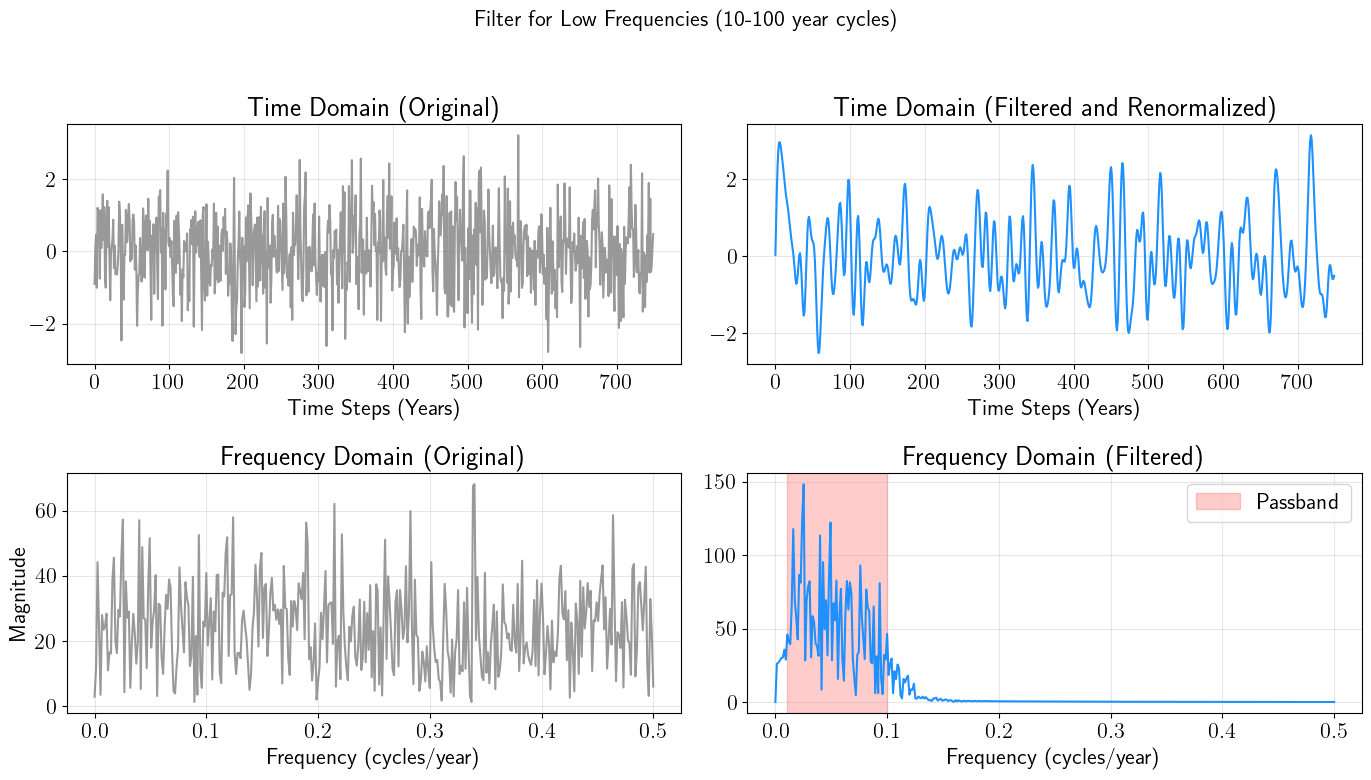

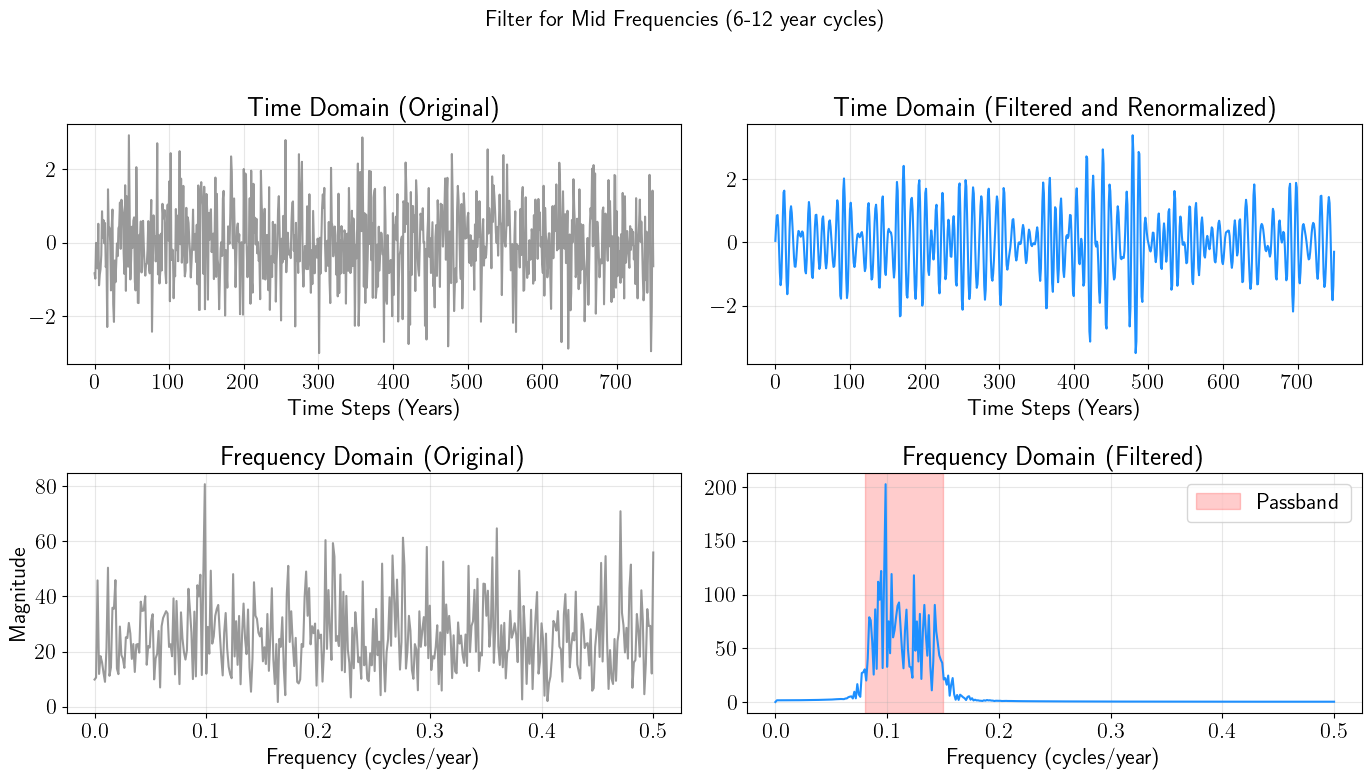

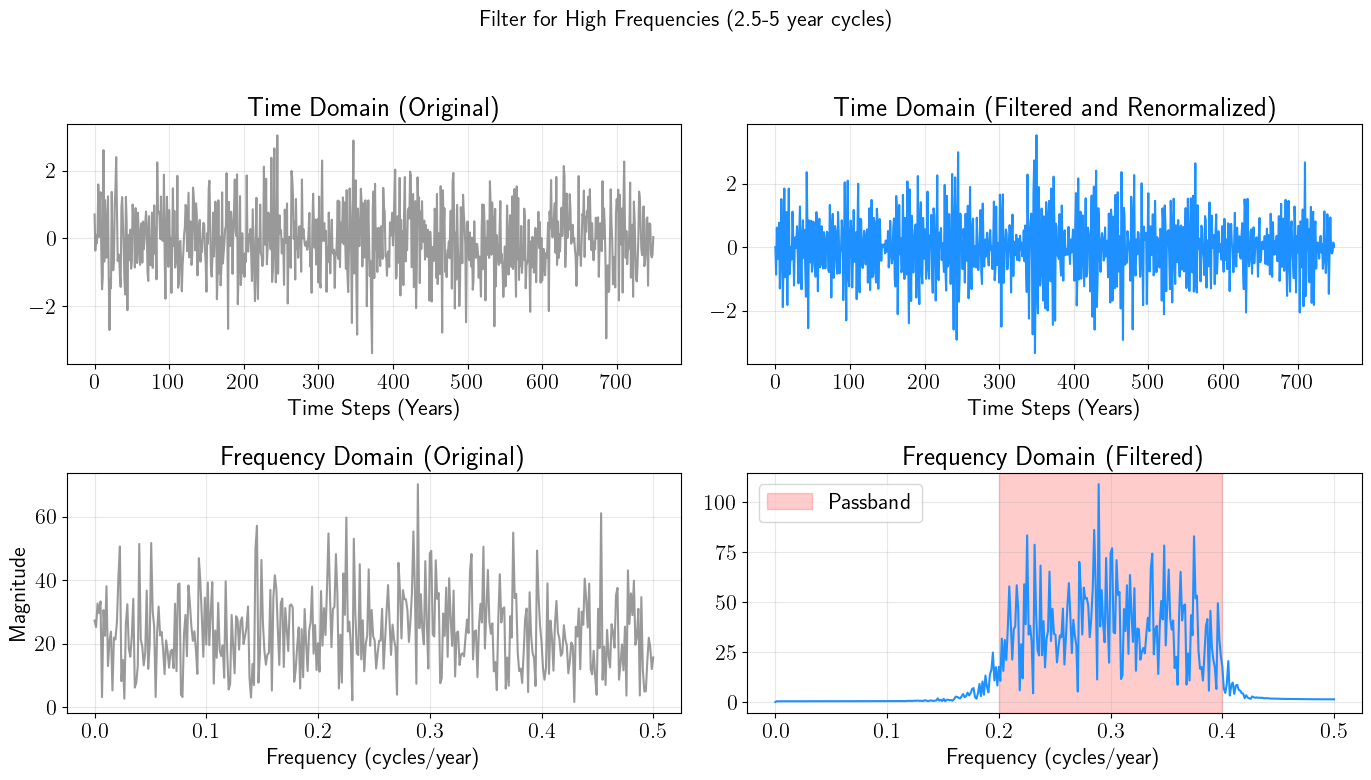

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import rfft, rfftfreq

def create_and_plot_bandpass_noise(n_steps, fs, f_low, f_high, title):
    """
    Generates, filters, renormalizes, and plots noise for verification.
    """
    # 1. Generate white noise and get its frequency spectrum
    white_noise = np.random.randn(n_steps)
    yf_white = rfft(white_noise)
    xf = rfftfreq(n_steps, 1 / fs)

    # 2. Design and apply a Butterworth bandpass filter
    # Frequencies are normalized to the Nyquist frequency (fs/2)
    nyquist = 0.5 * fs
    low = f_low / nyquist
    high = f_high / nyquist
    b, a = signal.butter(4, [low, high], btype='band')
    filtered_noise = signal.filtfilt(b, a, white_noise)

    # 3. Renormalize the filtered signal to have zero mean and unit std dev
    filtered_noise -= np.mean(filtered_noise)
    filtered_noise /= np.std(filtered_noise)
    yf_filtered = rfft(filtered_noise)
    
    # 4. Plot the results
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(title, fontsize=16)

    # Time domain plots
    axes[0, 0].plot(white_noise, label='Original White Noise', color='gray', alpha=0.8)
    axes[0, 0].set_title('Time Domain (Original)')
    axes[0, 0].set_xlabel('Time Steps (Years)')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(filtered_noise, label=f'Filtered Noise', color='dodgerblue')
    axes[0, 1].set_title('Time Domain (Filtered and Renormalized)')
    axes[0, 1].set_xlabel('Time Steps (Years)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Frequency domain plots
    axes[1, 0].plot(xf, np.abs(yf_white), color='gray', alpha=0.8)
    axes[1, 0].set_title('Frequency Domain (Original)')
    axes[1, 0].set_xlabel('Frequency (cycles/year)')
    axes[1, 0].set_ylabel('Magnitude')
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(xf, np.abs(yf_filtered), color='dodgerblue')
    axes[1, 1].axvspan(f_low, f_high, color='red', alpha=0.2, label='Passband')
    axes[1, 1].set_title('Frequency Domain (Filtered)')
    axes[1, 1].set_xlabel('Frequency (cycles/year)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- Run Verification with Arbitrary Frequency Ranges ---
N_STEPS = 750  # From 1750 to 2500
FS = 1         # Sampling rate is 1 sample per year

print("Displaying verification plots for bandpass filter...")
# Low-frequency (e.g., centennial cycles)
create_and_plot_bandpass_noise(N_STEPS, FS, 0.01, 0.1, 'Filter for Low Frequencies (10-100 year cycles)')
# Mid-frequency (e.g., decadal cycles)
create_and_plot_bandpass_noise(N_STEPS, FS, 0.08, 0.15, 'Filter for Mid Frequencies (6-12 year cycles)')
# High-frequency (e.g., interannual cycles like ENSO)
create_and_plot_bandpass_noise(N_STEPS, FS, 0.2, 0.4, 'Filter for High Frequencies (2.5-5 year cycles)')

In [46]:
import pandas as pd
from scipy import signal

# --- Search Configuration ---
USER_SIGMA = 100.0  # The standard deviation to apply after filtering
N_SAMPLES = 10     # Number of random trials for each frequency pair

# Define the grid of frequencies to search (in cycles/year)
low_cutoffs = [0.01, 0.05, 0.1, 0.2]   # Corresponds to periods of 100, 20, 10, 5 years
high_cutoffs = [0.05, 0.1, 0.2, 0.45] # Corresponds to periods of 20, 10, 5, ~2.2 years

results = []
print(f"\nStarting grid search for optimal frequency band...")
print(f"Using sigma = {USER_SIGMA} and {N_SAMPLES} samples per pair.")

# --- Main Grid Search Loop ---
for f_low in low_cutoffs:
    for f_high in high_cutoffs:
        # Ensure the low cutoff is less than the high cutoff
        if f_low >= f_high:
            continue

        print(f"--> Testing band: [{f_low:.2f}, {f_high:.2f}] cycles/year...")
        nrmse_for_pair = []

        # Sample n_sample times to account for stochasticity
        for i in range(N_SAMPLES):
            # 1. Generate and filter the noise
            white_noise = np.random.randn(n_steps)
            nyquist = 0.5 * FS
            b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
            filtered_noise = signal.filtfilt(b, a, white_noise)

            # 2. Renormalize to zero mean and unit standard deviation
            filtered_noise -= np.mean(filtered_noise)
            filtered_noise /= np.std(filtered_noise)

            # 3. Apply the user-specified sigma
            training_emissions_co2 = USER_SIGMA * filtered_noise

            # 4. Run the full FaIR and MLP evaluation
            scen_name = f'noise_f{f_low:.2f}-{f_high:.2f}_s{i}'
            f_train = run_fair.build_fair(start, stop)
            emis_train = {'CO2': training_emissions_co2}
            run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emis_train, n_steps))
            _, _, training_temp, _ = run_fair.run_fair(f_train, years)

            train_scenarios = [scen_name]
            train_series = [(training_emissions_co2, training_temp, None)]

            error_dict, _ = utils_MLP.evaluate_trainsets_vs_tests(
                train_scenarios, train_series,
                scenarios_valid, valid_series,
                random_state=None
            )

            scores_for_this_run = [
                error_dict[scen_name][scen_valid]
                for scen_valid in scenarios_valid
            ]
            nrmse_for_pair.append(np.mean(scores_for_this_run))

        # 5. Record the error statistics for this frequency pair
        results.append({
            'f_low': f_low,
            'f_high': f_high,
            'mean_nrmse': np.mean(nrmse_for_pair),
            'std_nrmse': np.std(nrmse_for_pair)
        })

# --- Display Final Results ---
results_df = pd.DataFrame(results).sort_values(by='mean_nrmse')

print("\n" + "="*55)
print("Grid Search for Optimal Frequency Band Complete")
print("="*55)
print(results_df.to_string(index=False))


Starting grid search for optimal frequency band...
Using sigma = 100.0 and 10 samples per pair.
--> Testing band: [0.01, 0.05] cycles/year...


Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

...

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]


Grid Search for Optimal Frequency Band Complete
 f_low  f_high  mean_nrmse  std_nrmse
  0.01    0.10    0.195100   0.119303
  0.01    0.20    0.196577   0.163854
  0.01    0.05    0.224237   0.111829
  0.01    0.45    0.235132   0.196038
  0.05    0.20    0.309429   0.152351
  0.10    0.20    0.375582   0.154623
  0.05    0.10    0.390538   0.205399
  0.05    0.45    0.427704   0.265850
  0.10    0.45    0.516292   0.277659
  0.20    0.45    0.655496   0.354980


#### 3. Test candidate mean trend profiles
Candidates for mean trend include: staircase with dwell (plateaus), slow ramp, sigmoid, piecewise ramp, sinusoid. All mean trend candidates must first sweep up and then down to cover both the warming and cooling regimes.

In [67]:
import numpy as np
import pandas as pd
from scipy.stats import qmc
from scipy import signal
import time

# --- ASSUMPTIONS ---
# The following objects are assumed to be pre-loaded in the environment:
# - n_steps:         (int) Number of time steps in the simulation.
# - FS:              (int) Sampling frequency (e.g., 1 for yearly data).
# - years:           (np.ndarray) Array of years for the simulation.
# - build_fair, run_fair, set_emissions, ensure_all_agents: (functions) Your FaIR helpers.
# - utils_MLP.evaluate_trainsets_vs_tests: (function) Your MLP evaluator.
# - scenarios_valid:  (list) A list of validation scenario names.
# - valid_series:    (list) The corresponding validation data series.
# ---------------------


# --- 1. Mean Function Definitions (m(t)) ---
# Define your candidate mean functions here. Each must accept `t` (time array)
# and its specific parameters as arguments.

def zero_mean(t):
  """A mean trend of zero."""
  return np.zeros_like(t)

def quadratic_overshoot(t, a, b):
  """A parabolic trend to simulate an overshoot scenario. t should be normalized."""
  t_norm = (t - t[0]) / (t[-1] - t[0]) # Normalize time from 0 to 1
  return a * t_norm**2 + b * t_norm

def sinusoidal_cycle(t, amplitude, frequency):
  """A long-period sinusoidal cycle."""
  return amplitude * np.sin(2 * np.pi * frequency * t)

# --- 2. Configuration ---
# All user-configurable settings are in this section.

# A dictionary mapping function names to the actual function and its parameter space.
MEAN_FUNCTIONS = {
  "zero": {
    "function": zero_mean,
    "params": {} # No parameters for this function
  },
  "quadratic": {
    "function": quadratic_overshoot,
    "params": {
        # Coeffs for m(t) = at^2 + bt
        "m_param_a": [-20.0, 0.0],  # `a` must be negative for an overshoot
        "m_param_b": [0.0, 50.0],
    }
  },
  "sinusoid": {
    "function": sinusoidal_cycle,
    "params": {
        "m_param_amplitude": [10.0, 75.0],
        "m_param_frequency": [0.0005, 0.005] # Periods of 200-2000 years
    }
  }
}

CONFIG = {
  "CHOSEN_MEAN_FUNCTION": "sinusoid", # Select candidate function
  "N_LHS_SAMPLES": 50,              # Number of parameter sets to test
  "N_INNER_SAMPLES": 20,             # Stochastic samples per parameter set

  # Define the parameter space for noise properties
  "NOISE_PARAM_SPACE": {
    "sigma": [50.0, 150.0], # Noise standard deviation
    "f_low": [0.01, 0.1],  # Low frequency cutoff [10 - 100 years]
    "f_high": [0.1, 0.25], # High frequency cutoff [2 - 5 years]
  }
}

# --- 3. Core Evaluation Function ---

def evaluate_parameter_set(params, mean_func):
  """
  Evaluates a single, complete set of parameters by sampling N times.
  `params` is a pandas Series or dict containing all parameter values.
  """
  nrmse_scores = []

  # Unpack parameters
  sigma, f_low, f_high = params['sigma'], params['f_low'], params['f_high']
  mean_func_params = {k.replace('m_param_', ''): v for k, v in params.items() if k.startswith('m_param_')}

  for i in range(CONFIG["N_INNER_SAMPLES"]):
    # A. Generate the mean trend m(t)
    m_t = mean_func(np.arange(n_steps), **mean_func_params)

    # B. Generate the band-limited noise w(t)
    white_noise = np.random.randn(n_steps)
    nyquist = 0.5 * FS
    b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
    w_t = signal.filtfilt(b, a, white_noise)
    w_t -= np.mean(w_t)
    w_t /= np.std(w_t)

    # C. Construct the final training signal u(t)
    u_t = m_t + sigma * w_t

    # D. Run the FaIR + MLP evaluation pipeline
    f_train = run_fair.build_fair(start, stop)
    emis_train = {'CO2': u_t}
    run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emis_train, n_steps))
    _, _, training_temp, _ = run_fair.run_fair(f_train, years)

    train_scenarios = ["lhs_training_run"]
    train_series = [(u_t, training_temp, None)]

    error_dict, _ = utils_MLP.evaluate_trainsets_vs_tests(
      train_scenarios, train_series, scenarios_valid, valid_series
    )

    # E. Calculate and store the performance score for this inner sample
    scores_for_this_run = [err for err in error_dict["lhs_training_run"].values()]
    nrmse_scores.append(np.mean(scores_for_this_run))

  # Return the statistics over the inner samples
  return np.mean(nrmse_scores), np.std(nrmse_scores)


# --- 4. Main Execution Block ---

if __name__ == "__main__":
  # A. Select the mean function and construct the full parameter space
  chosen_config = MEAN_FUNCTIONS[CONFIG["CHOSEN_MEAN_FUNCTION"]]
  mean_function_to_run = chosen_config["function"]

  full_param_space = {**CONFIG["NOISE_PARAM_SPACE"], **chosen_config["params"]}
  param_names = list(full_param_space.keys())
  l_bounds = [p[0] for p in full_param_space.values()]
  u_bounds = [p[1] for p in full_param_space.values()]
  D = len(full_param_space)

  print(f"Begin Optimization...")
  print(f"Mean Function: '{CONFIG['CHOSEN_MEAN_FUNCTION']}'")
  print(f"Number of LHS Samples: {CONFIG['N_LHS_SAMPLES']}")
  print(f"Stochastic Samples per Set: {CONFIG['N_INNER_SAMPLES']}")
  print(f"Optimizing over {D} parameters: {param_names}\n")

  # B. Generate parameter sets using Latin Hypercube Sampling
  sampler = qmc.LatinHypercube(d=D, seed=42)
  unit_samples = sampler.random(n=CONFIG["N_LHS_SAMPLES"])
  scaled_samples = qmc.scale(unit_samples, l_bounds, u_bounds)
  experiments_df = pd.DataFrame(scaled_samples, columns=param_names)

  # Ensure f_low is always less than f_high
  mask = experiments_df['f_low'] > experiments_df['f_high']
  experiments_df.loc[mask, ['f_low', 'f_high']] = experiments_df.loc[mask, ['f_high', 'f_low']].values

  # C. Loop through experiments and evaluate each one
  results = []
  start_time = time.time()
  for index, params in experiments_df.iterrows():
    print(f"--> Running Experiment {index + 1}/{CONFIG['N_LHS_SAMPLES']}...")

    mean_nrmse, std_nrmse = evaluate_parameter_set(params, mean_function_to_run)

    # Store results
    result_row = {**params, 'mean_nrmse': mean_nrmse, 'std_nrmse': std_nrmse}
    results.append(result_row)
    print(f"    Done. Mean NRMSE: {mean_nrmse:.4f} +/- {std_nrmse:.4f}")

  end_time = time.time()
  print(f"\nAll experiments completed in {end_time - start_time:.2f} seconds.")

  # D. Display final ranked results
  results_df = pd.DataFrame(results).sort_values(by='mean_nrmse').reset_index(drop=True)

print("\n" + "="*94)
print("                     Optimal Parameter Set Results (Ranked by Mean NRMSE)")
print("="*94)
print(results_df.to_string())

Begin Optimization...
Mean Function: 'sinusoid'
Number of LHS Samples: 50
Stochastic Samples per Set: 20
Optimizing over 5 parameters: ['sigma', 'f_low', 'f_high', 'm_param_amplitude', 'm_param_frequency']

--> Running Experiment 1/50...
    Done. Mean NRMSE: 0.1209 +/- 0.0456
--> Running Experiment 2/50...
    Done. Mean NRMSE: 0.0809 +/- 0.0201
--> Running Experiment 3/50...
    Done. Mean NRMSE: 0.1080 +/- 0.0263
--> Running Experiment 4/50...
    Done. Mean NRMSE: 0.1617 +/- 0.0286
--> Running Experiment 5/50...
    Done. Mean NRMSE: 0.0785 +/- 0.0157
--> Running Experiment 6/50...
    Done. Mean NRMSE: 0.1181 +/- 0.0163
--> Running Experiment 7/50...
    Done. Mean NRMSE: 0.0787 +/- 0.0187
--> Running Experiment 8/50...
    Done. Mean NRMSE: 0.2525 +/- 0.1313
--> Running Experiment 9/50...
    Done. Mean NRMSE: 0.0896 +/- 0.0258
--> Running Experiment 10/50...
    Done. Mean NRMSE: 0.0782 +/- 0.0087
--> Running Experiment 11/50...
    Done. Mean NRMSE: 0.1213 +/- 0.0187
--> Runnin

/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:245: RuntimeWarning: invalid value encountered in log
  * np.log(co2 / co2_base)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:257: RuntimeWarning: invalid value encountered in sqrt
  (a2 * np.sqrt(co2) + b2 * np.sqrt(n2o) + c2 * np.sqrt(ch4) + d2)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:245: RuntimeWarning: invalid value encountered in log
  * np.log(co2 / co2_base)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:257: RuntimeWarning: invalid value encountered in sqrt
  (a2 * np.sqrt(co2) + b2 * np.sqrt(n2o) + c2 * np.sqrt(ch4) + d2)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:245: RuntimeWarning: invalid value encountered in log
  * np.log(co2 / co2_base)
/Users/chriswomack/anaconda3/envs/research/lib/python

    Done. Mean NRMSE: 0.1930 +/- 0.0854
--> Running Experiment 42/50...
    Done. Mean NRMSE: 0.0671 +/- 0.0090
--> Running Experiment 43/50...
    Done. Mean NRMSE: 0.0859 +/- 0.0256
--> Running Experiment 44/50...
    Done. Mean NRMSE: 0.1437 +/- 0.0287
--> Running Experiment 45/50...
    Done. Mean NRMSE: 0.0761 +/- 0.0110
--> Running Experiment 46/50...
    Done. Mean NRMSE: 0.2775 +/- 0.0264
--> Running Experiment 47/50...
    Done. Mean NRMSE: 0.1284 +/- 0.0213
--> Running Experiment 48/50...
    Done. Mean NRMSE: 0.0842 +/- 0.0270
--> Running Experiment 49/50...
    Done. Mean NRMSE: 0.1120 +/- 0.0545
--> Running Experiment 50/50...
    Done. Mean NRMSE: 0.4279 +/- 0.0602

All experiments completed in 1131.76 seconds.

                     Optimal Parameter Set Results (Ranked by Mean NRMSE)
         sigma     f_low    f_high  m_param_amplitude  m_param_frequency  mean_nrmse  std_nrmse
0    61.540688  0.040363  0.115967          39.741618           0.002614    0.067053   0.00896

In [62]:
def plot_top_n_scenarios(results_df, n, mean_func):
  """
  Reconstructs, runs, and plots the top n best-performing training signals.

  Args:
      results_df (pd.DataFrame): The final, sorted DataFrame from the LHS optimization.
      n (int): The number of top scenarios to plot.
      mean_func (function): The handle to the mean function used (e.g., quadratic_overshoot).
  """

  top_n_df = results_df.head(n)

  for i, (index, params) in enumerate(top_n_df.iterrows()):
    # 1. Unpack the parameters for this scenario
    sigma, f_low, f_high = params['sigma'], params['f_low'], params['f_high']
    mean_func_params = {k.replace('m_param_', ''): v for k, v in params.items() if k.startswith('m_param_')}

    # 2. Reconstruct one instance of the training signal u(t)
    m_t = mean_func(np.arange(n_steps), **mean_func_params)

    white_noise = np.random.randn(n_steps)
    nyquist = 0.5 * FS
    b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
    w_t = signal.filtfilt(b, a, white_noise)
    w_t -= np.mean(w_t)
    w_t /= np.std(w_t)
    noise_component = sigma * w_t

    u_t = m_t + noise_component

    # 3. Run this single signal through FaIR to get the temperature
    f_run = run_fair.build_fair(start, stop)
    emis_run = {'CO2': u_t}
    run_fair.set_emissions(f_run, years, run_fair.ensure_all_agents(emis_run, n_steps))
    _, _, temp_response, _ = run_fair.run_fair(f_run, years)

    # 4. Create the plots
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"Rank {i+1}: Optimal Training Signal (Mean NRMSE = {params['mean_nrmse']:.4f})", fontsize=16)

    # Plot 1: Input emissions signal components
    axes[0].plot(years, u_t, color='black', label='u(t): Total Emissions', lw=2)
    axes[0].plot(years, m_t, color='red', label='m(t): Mean Trend', ls='--', lw=2)
    axes[0].plot(years, noise_component, color='gray', label=r'$\sigma w(t)$: Noise Component', alpha=0.6)
    axes[0].set_ylabel(r'CO$_2$ Emissions (GtC/yr)')
    axes[0].set_title('Input Training Signal Components')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Output temperature response
    axes[1].plot(years, temp_response, color='darkorange', label='GMST Anomaly', lw=2)
    axes[1].set_ylabel(r'Temperature Anomaly ($^\circ$C)')
    axes[1].set_title('FaIR Model Temperature Response')
    axes[1].set_xlabel('Year')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


                     Optimal Parameter Set Results (Ranked by Mean NRMSE)
         sigma     f_low    f_high  m_param_amplitude  m_param_frequency  mean_nrmse  std_nrmse
0    61.540688  0.040363  0.115967          39.741618           0.002614    0.067053   0.008963
1    55.258155  0.069706  0.103575          38.187719           0.001944    0.071927   0.012765
2    84.126374  0.041966  0.174632          21.919554           0.002106    0.072313   0.021052
3    79.398103  0.055921  0.194011          50.357690           0.004164    0.076059   0.011038
4    71.570831  0.012865  0.232440          12.295879           0.001035    0.076519   0.045512
5    73.026683  0.072117  0.208187          14.456754           0.001267    0.076684   0.011357
6    82.892841  0.032393  0.237088          24.259937           0.002891    0.077537   0.018755
7    86.831804  0.050230  0.153747          40.659450           0.001936    0.078181   0.015673
8   121.658814  0.051535  0.167257          17.349069        

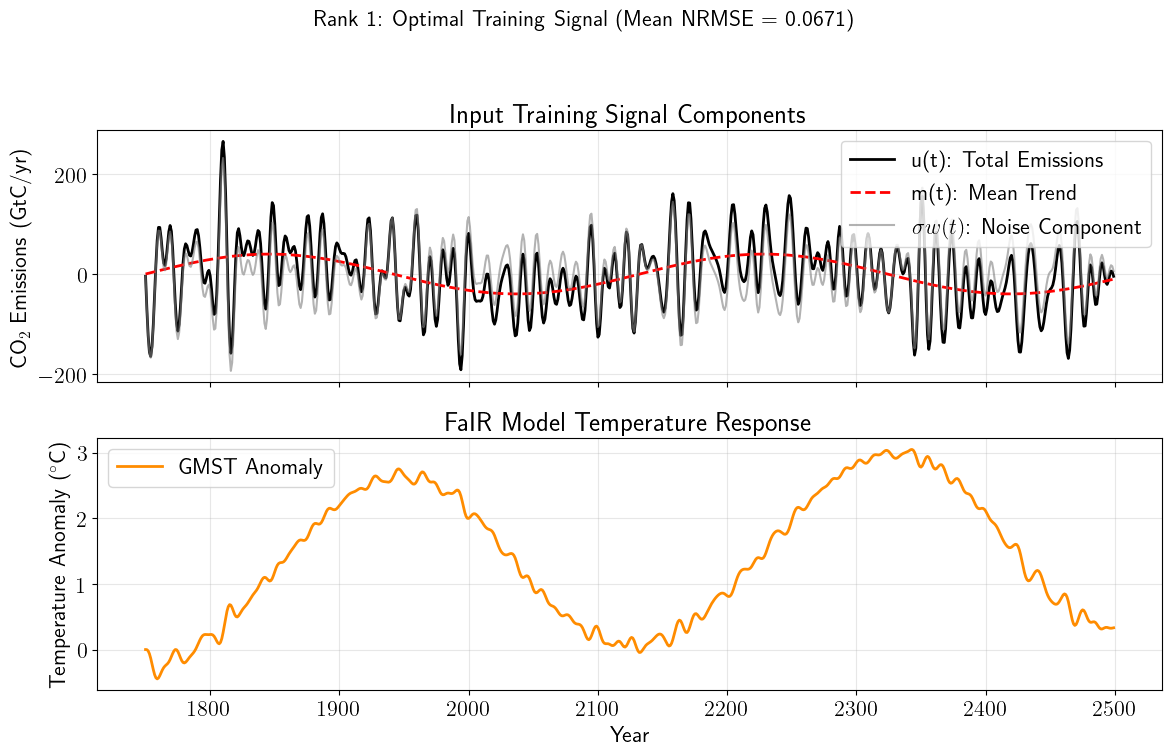

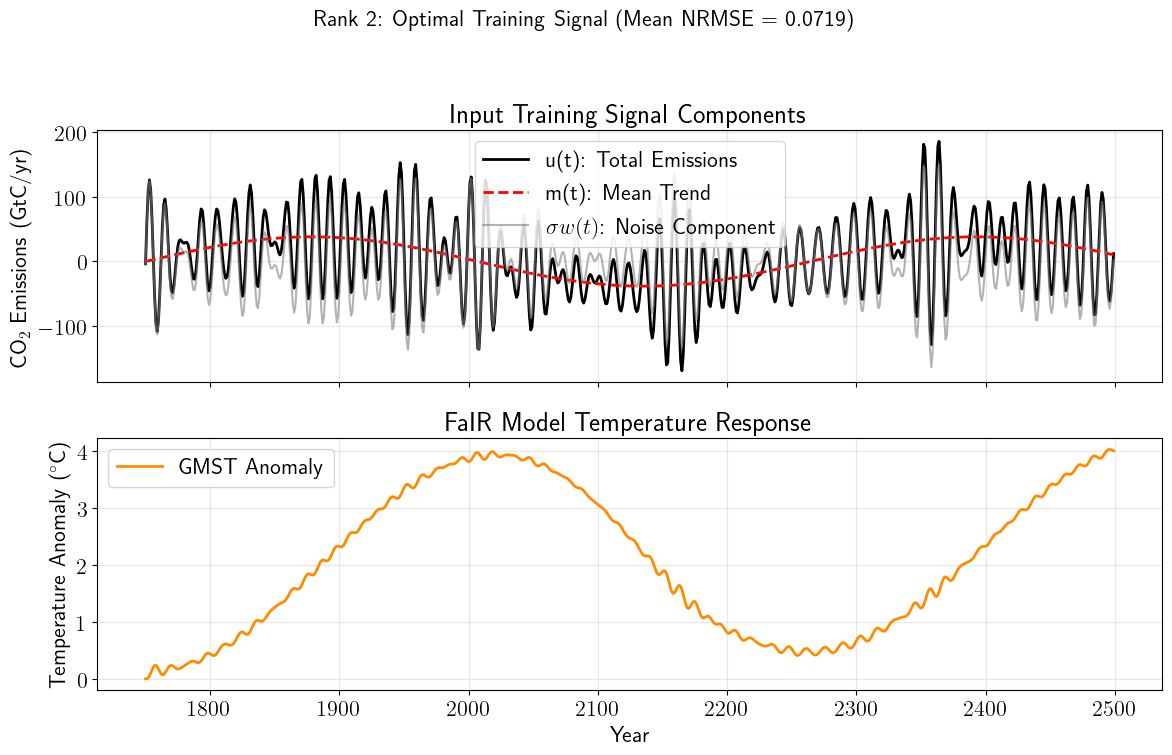

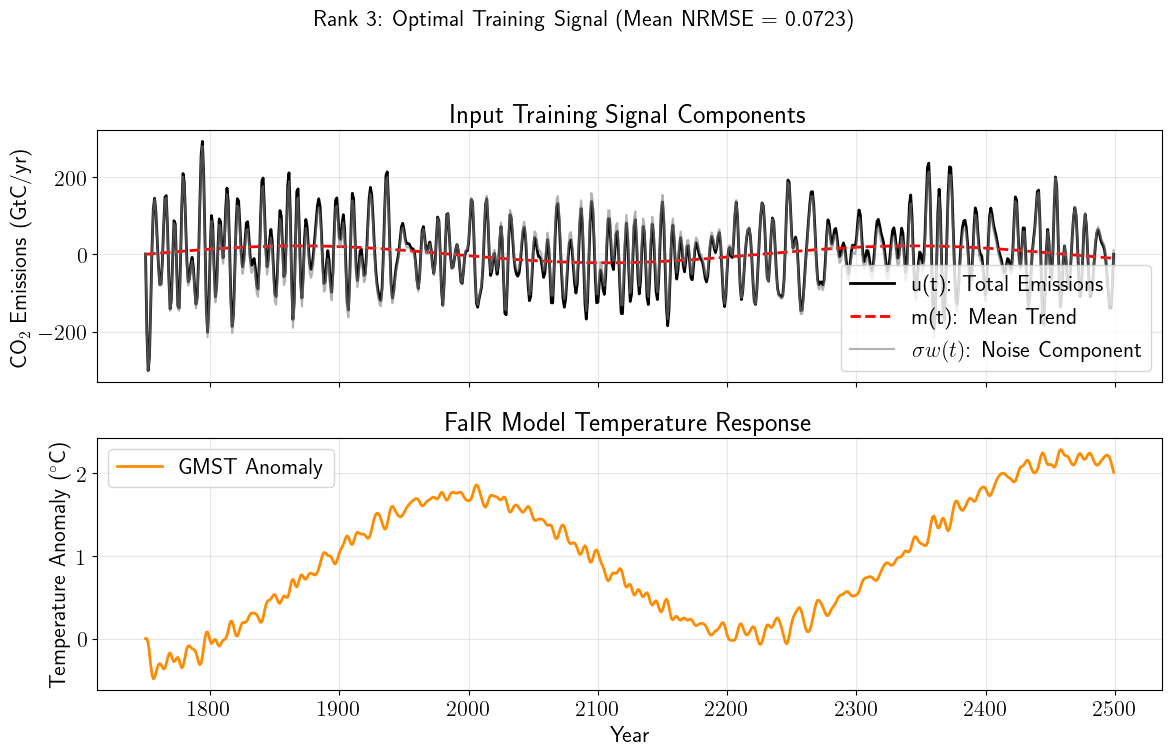

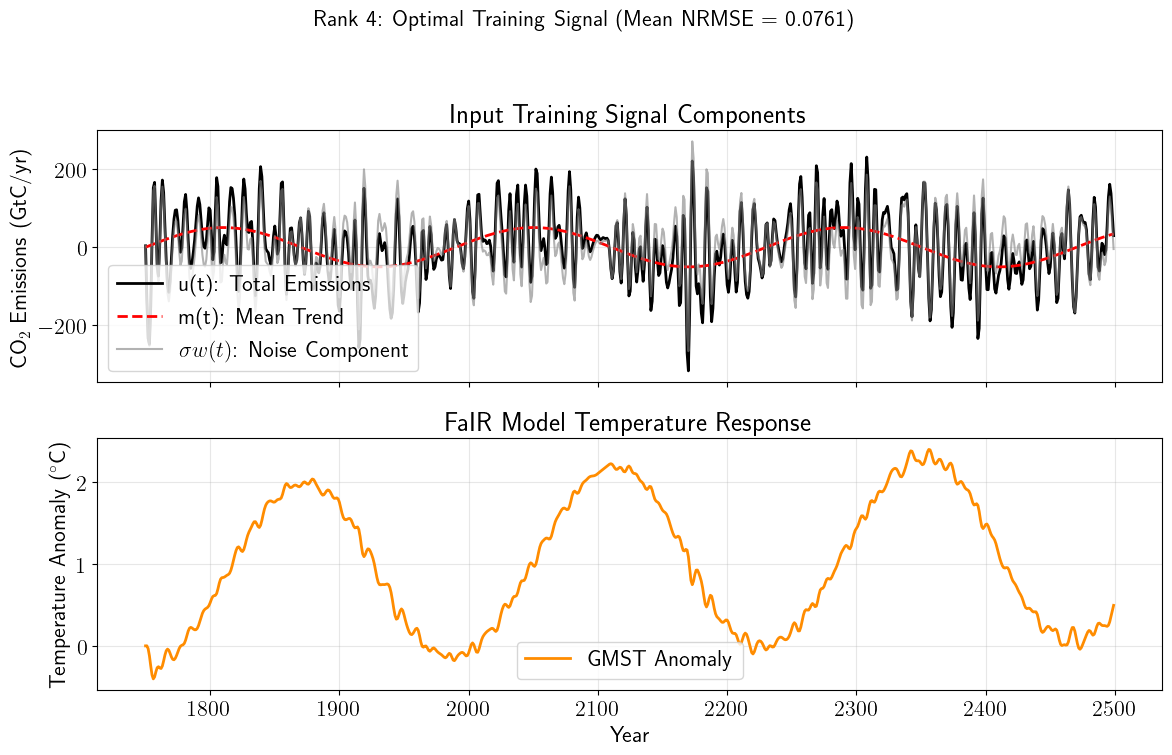

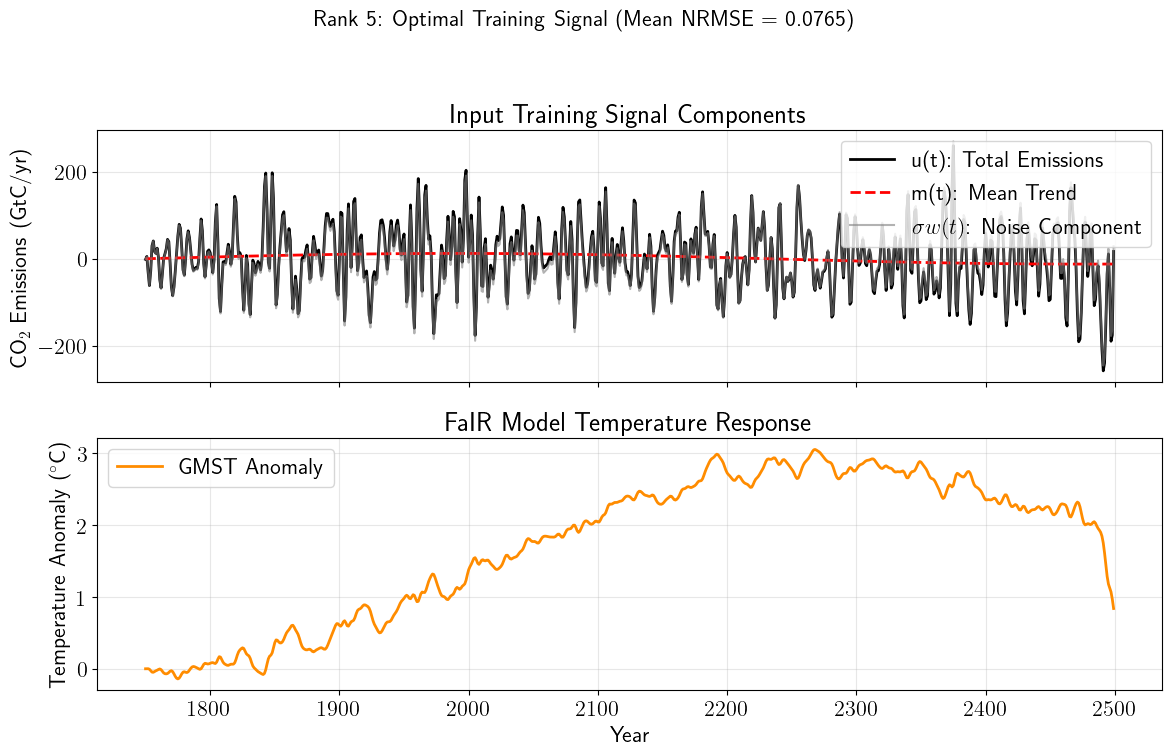

In [68]:
# --- Main Execution Block from previous script ---
# ... (all the LHS and evaluation loops) ...

# D. Display final ranked results
results_df = pd.DataFrame(results).sort_values(by='mean_nrmse').reset_index(drop=True)

print("\n" + "="*95)
print("                     Optimal Parameter Set Results (Ranked by Mean NRMSE)")
print("="*95)
print(results_df.to_string())

# E. NEW: Plot the top 3 best-performing signals
plot_top_n_scenarios(
  results_df=results_df,
  n=5,
  mean_func=mean_function_to_run
)